In [1]:
import numpy as np
import pint
from poincare import Simulator

from jablonski import (
    SingletState,
    SpectroscopicSystem,
    initial,
    transitions,
)
from jablonski.simulation import (
    delta_excitation,
    piecewise,
    pulse_excitation,
    spectral_time_resolved_emission,
)

u = pint.get_application_registry()


class Model(SpectroscopicSystem):
    low: SingletState = initial(4.5 * u.eV, "singlet", default=100)
    mid: SingletState = initial(5 * u.eV, "singlet", default=100)
    high: SingletState = initial(7.5 * u.eV, "singlet", default=0)

    absorption_1 = transitions.Absorption(ground=low, excited=high, rate=1e-1 / u.s)
    absorption_2 = transitions.Absorption(ground=low, excited=mid, rate=2e-1 / u.s)
    absorption_3 = transitions.Absorption(ground=mid, excited=high, rate=0.5e-1 / u.s)
    emission_1 = transitions.Fluorescence(ground=low, excited=mid, rate=2e-2 / u.s)
    emission_2 = transitions.Fluorescence(ground=mid, excited=high, rate=0.5e-1 / u.s)
    emission_3 = transitions.Fluorescence(ground=low, excited=high, rate=1e-1 / u.s)


sim = Simulator(Model)

C:\Users\olive\dyscolab\u2602\jablonski\src\jablonski\transitions.py:75: UserWarning: {obj!r} rate ({rate} Hz) is not within expected range high ({mn}-{mx} Hz).
  _check_range(self, "rate", 1e14, 1e16)
C:\Users\olive\dyscolab\u2602\jablonski\src\jablonski\transitions.py:208: UserWarning: {obj!r} rate ({rate} Hz) is not within expected range high ({mn}-{mx} Hz).
  _check_range(self, "rate", 1e7, 1e10)


<Axes: xlabel='time'>

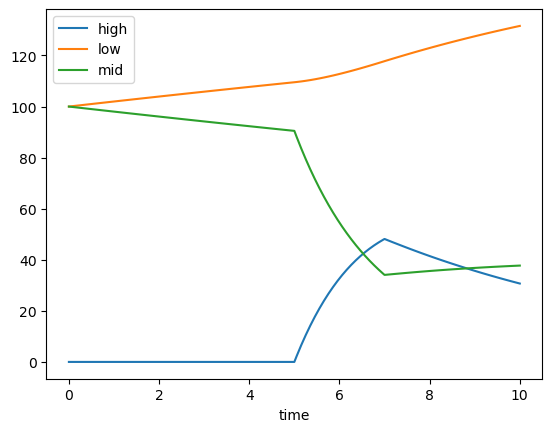

In [3]:
# Picewise simulation with a delta excitation at t = 0 and a pulse between t = 5 and t = 7
delta = delta_excitation(
    Model.absorption_3, start=0 * u.s, area=1 * u.s
)  # delta excitiation
pulse = pulse_excitation(
    Model.absorption_3, start=5, width=2, height=10
)  # delta excitiation
result_1 = piecewise(sim, events=delta | pulse, save_at=np.linspace(0, 10, 100))
result_1.to_dataframe().plot()

In [7]:
result_1

<xarray.Dataset> Size: 3kB
Dimensions:  (time: 103)
Coordinates:
  * time     (time) float64 824B 0.0 5e-11 0.101 0.202 ... 9.798 9.899 10.0
Data variables:
    high     (time) float64 824B 0.0 0.0 98.99 98.0 ... 31.18 30.72 30.25 29.8
    low      (time) float64 824B 100.0 100.0 101.0 102.0 ... 161.0 161.4 161.7
    mid      (time) float64 824B 100.0 100.0 4.95e-09 ... 8.236 8.373 8.507

line_emission_1: 0.5 electron_volt
line_emission_2: 2.5 electron_volt
line_emission_3: 3.0 electron_volt


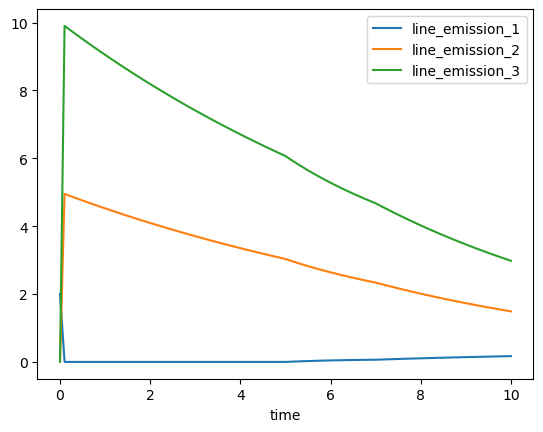

In [ ]:
# spectral time resolved emission for same excitation
result_2 = spectral_time_resolved_emission(
    Model, excitation=delta | pulse, save_at=np.linspace(0, 10, 100)
)
result_2.pint.dequantify().to_dataframe().plot()

# We can see each lines energy in the Datasets attributes
for line, energy in result_2.attrs.items():
    print(f"{line}: {energy}")

<Axes: xlabel='time'>

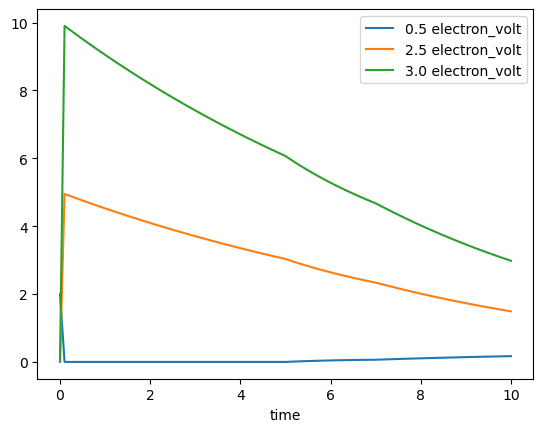

In [ ]:
# join_by_energy groups lines of the same energy and outputs energy instead of name
result_2 = spectral_time_resolved_emission(
    Model,
    excitation=delta | pulse,
    save_at=np.linspace(0, 10, 100),
    join_by_energy=True,
)
result_2.pint.dequantify().to_dataframe().plot()